# 🗺️ Modelo C — Clasificación de Agresividad de Ruta
## K-Means (Clustering Geoespacial) + Random Forest (Clasificador)

**Objetivo**: Segmentar y clasificar vías mineras en Verde / Amarilla / Roja
**Input**: latitud, longitud, vibracion_g, presion_psi, velocidad_kmh
**Output**: Etiqueta de severidad + score + cluster geoespacial

---

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
    silhouette_score, accuracy_score, f1_score)
from sklearn.pipeline import Pipeline

np.random.seed(42)
DATA_PATH = Path("../EDA/telemetria_bambas_2026_enero.csv")
MODEL_DIR = Path("./artifacts/modelo_C")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Librerías OK")

Librerías OK


## 2. Carga y Preparación de Features de Ruta

In [2]:
print("Cargando dataset...")
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
print(f"Shape: {df.shape}")

# Features para clustering geoespacial
ROUTE_FEATURES = ["latitud", "longitud", "vibracion_g", "presion_psi", "velocidad_kmh"]
df_route = df[ROUTE_FEATURES].dropna().copy()

# Feature de interacción: estrés mecánico
df_route["estres_mecanico"] = df_route["vibracion_g"] * df_route["velocidad_kmh"]

# Muestra para clustering (max 100k puntos)
if len(df_route) > 100000:
    df_route = df_route.sample(100000, random_state=42).reset_index(drop=True)

print(f"Dataset clustering: {df_route.shape}")
df_route.describe().round(2)

Cargando dataset...
Shape: (259560, 22)
Dataset clustering: (100000, 6)


,latitud,longitud,vibracion_g,presion_psi,velocidad_kmh,estres_mecanico
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,-14.09,-72.28,1.59,110.55,22.52,42.59
std,0.00,0.00,0.97,3.98,10.44,29.47
min,-14.09,-72.29,-0.15,100.00,0.00,-3.72
25%,-14.09,-72.28,0.98,107.30,20.70,22.68
50%,-14.09,-72.28,1.44,110.40,25.60,37.36
75%,-14.09,-72.28,2.37,113.80,29.20,64.77
max,-14.08,-72.28,5.18,123.70,46.10,162.34


## 3. K-Means: Determinación del K Óptimo

Evaluando K óptimo...
  K=2: Inercia=318985, Silhouette=0.4156
  K=3: Inercia=210236, Silhouette=0.4430
  K=4: Inercia=177743, Silhouette=0.3703
  K=5: Inercia=146584, Silhouette=0.3286
  K=6: Inercia=133494, Silhouette=0.3222
  K=7: Inercia=120931, Silhouette=0.3067
✅ K óptimo: 3 (Silhouette=0.4430)


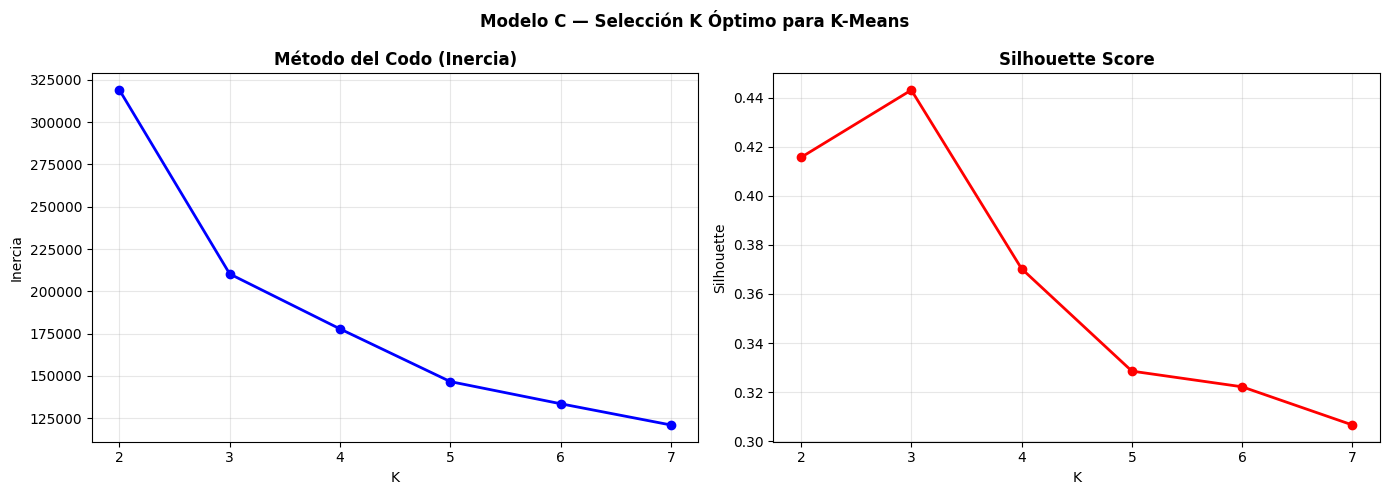

In [3]:
# Normalizar para clustering
scaler_c = StandardScaler()
X_scaled = scaler_c.fit_transform(df_route)

# Elbow method + Silhouette
K_RANGE = range(2, 8)
inertias, silhouettes = [], []

print("Evaluando K óptimo...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled[:10000], labels[:10000])
    silhouettes.append(sil)
    print(f"  K={k}: Inercia={km.inertia_:.0f}, Silhouette={sil:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_RANGE, inertias, "bo-", linewidth=2)
axes[0].set_title("Método del Codo (Inercia)", fontweight="bold")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inercia")
axes[0].grid(alpha=0.3)

axes[1].plot(K_RANGE, silhouettes, "ro-", linewidth=2)
axes[1].set_title("Silhouette Score", fontweight="bold")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette")
axes[1].grid(alpha=0.3)

best_k_idx = np.argmax(silhouettes)
best_k = list(K_RANGE)[best_k_idx]
print(f"✅ K óptimo: {best_k} (Silhouette={silhouettes[best_k_idx]:.4f})")
plt.suptitle("Modelo C — Selección K Óptimo para K-Means", fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "kmeans_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. K-Means Final con K=3

In [4]:
K_FINAL = 3  # Verde / Amarilla / Roja
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20, max_iter=500)
df_route["cluster"] = kmeans.fit_predict(X_scaled)

# Asignar etiquetas según vibracion_g media por cluster
cluster_stats = df_route.groupby("cluster")["vibracion_g"].mean().sort_values()
cluster_map = {}
for i, (cluster_id, _) in enumerate(cluster_stats.items()):
    cluster_map[cluster_id] = i  # 0=Verde, 1=Amarilla, 2=Roja

SEVERIDAD_LABELS = {0: "VERDE", 1: "AMARILLA", 2: "ROJA"}
df_route["severidad_id"] = df_route["cluster"].map(cluster_map)
df_route["severidad"] = df_route["severidad_id"].map(SEVERIDAD_LABELS)

print("Distribución de clusters:")
print(df_route.groupby("severidad")["vibracion_g"].agg(["count", "mean", "std"]).round(3))

# Guardar K-Means
joblib.dump(kmeans, MODEL_DIR / "kmeans_route.pkl")
print("✅ K-Means guardado")

Distribución de clusters:
           count   mean    std
severidad                     
AMARILLA   42857  1.202  0.298
ROJA       42070  2.522  0.589
VERDE      15073  0.103  0.058
✅ K-Means guardado


## 5. Random Forest Classifier

In [5]:
FEATURES_RF = ["latitud", "longitud", "vibracion_g", "presion_psi", "velocidad_kmh", "estres_mecanico"]

X = df_route[FEATURES_RF].values
y = df_route["severidad_id"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=5,
    class_weight="balanced", random_state=42, n_jobs=-1
)
print("Entrenando Random Forest...")
rf.fit(X_train, y_train)
print("✅ Random Forest entrenado")

# Métricas
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
cv_scores = cross_val_score(rf, X_train[:10000], y_train[:10000], cv=5, scoring="f1_macro")

print("" + "=" * 50)
print("📊 MÉTRICAS MODELO C (K-Means + Random Forest)")
print("=" * 50)
print(f"Accuracy: {acc:.4f}")
print(f"F1-Macro: {f1:.4f}  (objetivo: > 0.85)")
print(f"CV F1 (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Silhouette Score K-Means: {silhouette_score(X_scaled[:10000], kmeans.predict(X_scaled[:10000])):.4f}")
print("Reporte completo:")
print(classification_report(y_test, y_pred, target_names=["Verde", "Amarilla", "Roja"]))

Entrenando Random Forest...
✅ Random Forest entrenado
📊 MÉTRICAS MODELO C (K-Means + Random Forest)
Accuracy: 0.9977
F1-Macro: 0.9979  (objetivo: > 0.85)
CV F1 (5-fold): 0.9962 ± 0.0010
Silhouette Score K-Means: 0.4430
Reporte completo:
              precision    recall  f1-score   support

       Verde       1.00      1.00      1.00      3015
    Amarilla       1.00      1.00      1.00      8571
        Roja       1.00      1.00      1.00      8414

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



## 6. Visualizaciones

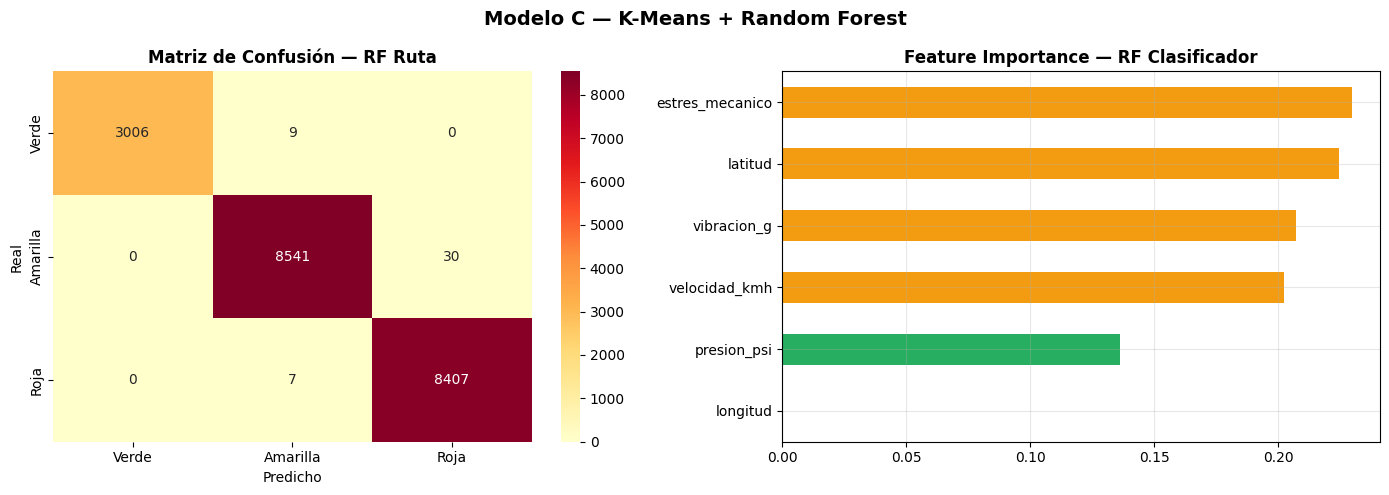

✅ Random Forest guardado: artifacts/modelo_C/rf_route_classifier.pkl
🎉 Modelo C listo! Consumir desde: app/services/route_service.py


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd", ax=axes[0],
            xticklabels=["Verde", "Amarilla", "Roja"], yticklabels=["Verde", "Amarilla", "Roja"])
axes[0].set_title("Matriz de Confusión — RF Ruta", fontweight="bold")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predicho")

# Feature Importance
fi = pd.Series(rf.feature_importances_, index=FEATURES_RF).sort_values()
colors = ["#27ae60" if v < 0.15 else "#f39c12" if v < 0.25 else "#e74c3c" for v in fi.values]
fi.plot(kind="barh", ax=axes[1], color=colors)
axes[1].set_title("Feature Importance — RF Clasificador", fontweight="bold")
axes[1].grid(alpha=0.3)

plt.suptitle("Modelo C — K-Means + Random Forest", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "evaluacion_rf.png", dpi=150, bbox_inches="tight")
plt.show()

joblib.dump(rf, MODEL_DIR / "rf_route_classifier.pkl")
print(f"✅ Random Forest guardado: {MODEL_DIR}/rf_route_classifier.pkl")
print("🎉 Modelo C listo! Consumir desde: app/services/route_service.py")